Let $H$ denote the subspace Hamiltonian whose ground state $E_\text{GS}$ we want to estimate. Due to finite sampling error on the matrix elements of $H$, we end up getting both uncertainty and bias in our estimator for $E_\text{GS}$. The mean $\mu$ of the biased estimator always satisfies $\mu \leq E_\text{GS}$ (proof: realize that the map $X \mapsto E_\text{GS}(X)$ is concave, and invoke Jensen's inequality). Nevertheless, the bias can be partially corrected for using second order perturbation theory. 

In this notebook, I want to demonstrate the presence of bias in the estimator of the ground state, and that second order perturbation theory can partially correct this bias.

In [2]:
import numpy as np
from numpy.random import uniform, normal
import matplotlib.pyplot as plt

In [ ]:
# simple, fixed, two-dimensional example

H = np.array([
    [-0.01, 0.02],
    [0.02, 0.03]
])

Eigs, Vecs = np.linalg.eigh(H)

E0   = Eigs[0]
E1   = Eigs[1]
psi0 = Vecs[:,0]
psi1 = Vecs[:,1]
gap  = E0 - E1 

sigma = 0.075

Nsamples     = 200000
E0_samples   = np.zeros(Nsamples)
corr_samples = np.zeros(Nsamples)

for i in range(Nsamples):
    R = normal(scale=sigma, size=[2,2])
    R = (R + R.T) / 2
    S = H + R

    gs_sample   = np.linalg.eigh(S)[0][0]
    corr_sample = np.abs(psi0 @ R @ psi1) ** 2 / gap

    E0_samples[i]   = gs_sample
    corr_samples[i] = corr_sample

    if i % 1000 == 0:
        print(i, end='\r')

print("sampling completed")

cumulative_E0_estimates = np.cumsum(E0_samples) / np.arange(1, Nsamples + 1)



sampling completed


sampling completed

    Error of sample mean           : 0.0434979402531806
    Error of corrected sample mean : -0.005198867745786321
    Remaining error percent        : 11.95



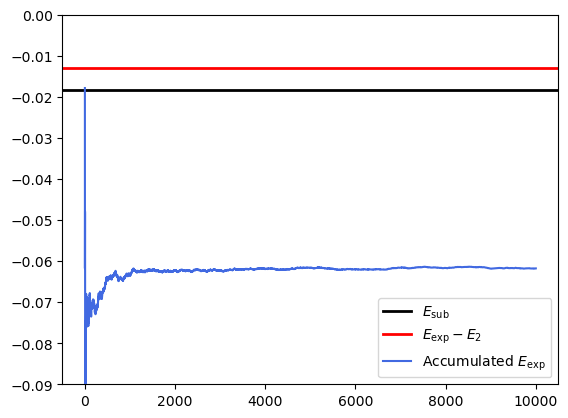

In [116]:
H = np.array([
    [-0.01, 0.02],
    [0.02, 0.03]
])

Eigs, Vecs = np.linalg.eigh(H)

Esub  = Eigs[0]
E1    = Eigs[1]
psi0  = Vecs[:,0]
psi1  = Vecs[:,1]
gap   = Esub - E1

sigma        = 0.075
Nsamples     = 10000
Esub_samples = np.zeros(Nsamples)
corr_samples = np.zeros(Nsamples)

for i in range(Nsamples):
    R = normal(scale=sigma, size=[2,2])
    R = (R + R.T) / 2
    S = H + R

    Esub_sample = np.linalg.eigh(S)[0][0]
    corr_sample = np.abs(psi0 @ R @ psi1) ** 2 / gap

    Esub_samples[i] = Esub_sample
    corr_samples[i] = corr_sample

    if i % 1000 == 0:
        print(i, end='\r')

print("sampling completed")

Eexp_running = np.cumsum(Esub_samples) / np.arange(1, Nsamples + 1)
Eexp         = np.mean(Esub_samples)
corr         = np.mean(corr_samples)

diff                    = Esub - Eexp
diff_corr               = Esub - (Eexp - corr)
remaining_error_percent = 100 * np.abs(diff_corr) / np.abs(diff)

print(f'''
    Error of sample mean           : {Esub - Eexp}
    Error of corrected sample mean : {Esub - (Eexp - corr)}
    Remaining error percent        : {np.round(100 * np.abs(diff_corr) / np.abs(diff), 2)}
''')

plt.figure()
plt.axhline(y=Esub, color='black', label=r'$E_\text{sub}$', linewidth=2)
plt.axhline(y=Eexp - corr, color='red', label=r'$E_\text{exp} - E_2$', linewidth=2)
plt.plot(range(Nsamples), Eexp_running, zorder=10, color='royalblue', label=r'Accumulated $E_\text{exp}$')
plt.ylim(-0.09, 0.00)
plt.legend()